Import de paquets

In [1]:
import os
import random
import pandas as pd
import numpy as np
import torch
from torch import randperm
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, SubsetRandomSampler
from torchvision import datasets, transforms, models
from torchvision.transforms import v2
from torchmetrics.classification import BinaryAccuracy, BinaryConfusionMatrix
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import my_helper
import logging
from tqdm import tqdm
import shutil
from glob import glob
import optuna
import optuna.trial
import mlflow
import mlflow.pytorch
from packaging import requirements
from pprint import pformat
from IPython.display import display, Image

In [2]:
#logger = logging.getLogger("mlflow")
#logger.setLevel(logging.DEBUG)

seed pour la reproductibilité   

In [3]:
def set_seed(seed=42):
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

vérification et choix du GPU si disponible

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du périphérique : {device}")

Utilisation du périphérique : cuda


In [5]:
# 1. Définition des chemins (ajustez-les si nécessaire)
source_dir = os.getcwd()+"\\data\\Cat_Dog_data"
target_dir = os.getcwd()+ "\\data\\Cat_Dog_ordered"

os.makedirs(target_dir, exist_ok=True)

# 2. Création de la nouvelle structure de dossier
for label in ["cat", "dog"]:
    os.makedirs(os.path.join(target_dir, label), exist_ok=True)

print("Début du déplacement des images...")

# 3. Recherche et déplacement des images
# Le pattern '*' englobe 'train' et 'test', et le deuxième '*' englobe les extensions (jpg, png, etc.)
search_pattern = os.path.join(source_dir, "*", "*", "*")
files = glob(search_pattern)

moved_count = 0

for file_path in files:
    # On vérifie qu'il s'agit bien d'un fichier et non d'un dossier
    if os.path.isfile(file_path):
        # On extrait les composants du chemin
        # Exemple : 'Cat_Dog_data/train/cat/img_1.jpg' -> ['Cat_Dog_data', 'train', 'cat', 'img_1.jpg']
        path_parts = file_path.split(os.sep)
        
        # Le label ('cat' ou 'dog') est l'avant-dernier élément
        label = path_parts[-2] 
        filename = path_parts[-1]
        
        if label in ["cat", "dog"]:
            # Pour éviter que des images de 'train' et 'test' ayant le même nom se détruisent,
            # on ajoute un préfixe (ex: 'train_img_1.jpg')
            subfolder = path_parts[-3] # 'train' ou 'test'
            new_filename = f"{subfolder}_{filename}"
            
            # Chemin de destination
            destination = os.path.join(target_dir, label, new_filename)
            
            # Déplacement du fichier
            shutil.move(file_path, destination)
            moved_count += 1

print(f"Terminé ! {moved_count} images ont été déplacées avec succès dans '{target_dir}'.")

Début du déplacement des images...
Terminé ! 0 images ont été déplacées avec succès dans 'c:\Users\dodzi\Documents\Codes Python\cnn-catsdogs-AHNERTDodzi\data\Cat_Dog_ordered'.


In [ ]:
params = {
    "Experiment": "CNN_Cats&Dogs_Experiments",
    "data_dir": "data/Cat_Dog_ordered",
    "batch_size": 32,
    "num_workers": 4,
    "train_size": 0.8,
    "val_size": 0.1,
    "test_size": 0.1,
    "epochs": 20,
    "dropout": 0.5,
    "save_path": "best_scratch_model.pth"
}

Préparation des focntion de transformation et augmentation de données avec redimensionnement, 50% aléatoire de rotation de 15%, rotation horizontale de l'image, ainsi que normalisation de l'image pour train et redimensionnement et normalisation des données de test et validation.

In [7]:
train_transforms = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])
test_val_transforms = v2.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])




In [8]:

def get_data_loaders(data_dir, batch_size, train_size, valid_size, num_workers, train_transforms, test_val_transforms):
    train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)
    test_val_dataset = datasets.ImageFolder(root=data_dir, transform=test_val_transforms)
    
    n_tot = len(train_dataset)
    
    # 2. Calculer la taille des segments (80% / 10% / 10%)
    split_train = int(np.floor(train_size * n_tot))
    split_val = int(np.floor((train_size + valid_size) * n_tot))
    
    # 3. Mélanger et séparer les indices de manière aléatoire
    shuffled_indices = randperm(n_tot).tolist()
    
    train_idx = shuffled_indices[:split_train]
    valid_idx = shuffled_indices[split_train:split_val]
    test_idx = shuffled_indices[split_val:]
    
    # 4. Définir les samplers basés sur les indices
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)
    test_sampler = SubsetRandomSampler(test_idx)
    
    # 5. Créer les DataLoaders
    # Note : On applique le train_dataset uniquement au train_loader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers, persistent_workers=True, pin_memory=True,prefetch_factor=2)
    valid_loader = DataLoader(test_val_dataset, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers, persistent_workers=True, pin_memory=True,prefetch_factor=2)
    test_loader = DataLoader(test_val_dataset, batch_size=batch_size, sampler=test_sampler, num_workers=num_workers, persistent_workers=True, pin_memory=True,prefetch_factor=2)
    
    return train_loader, valid_loader, test_loader

# --- Instanciation des DataLoaders ---
train_dl, valid_dl, test_dl = get_data_loaders(
    data_dir=params["data_dir"],
    batch_size=params["batch_size"],
    train_size=params["train_size"],
    valid_size=params["val_size"],
    num_workers=params["num_workers"],
    train_transforms=train_transforms,
    test_val_transforms=test_val_transforms
)

# Regroupement dans le dictionnaire final
data_loaders = {
    'train': train_dl,
    'val': valid_dl,
    'test': test_dl
}

In [9]:
classes = train_dl.dataset.classes
print(f"Classes : {classes}")
num_classes = len(classes)
print(f"Nombre de classes : {num_classes}")

Classes : ['cat', 'dog']
Nombre de classes : 2


Nombre de batchs pour train, val et test

In [10]:
print(len(data_loaders['train']), len(data_loaders['val']), len(data_loaders['test']))

625 79 79


Test des loaders

tensor([1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 1, 0, 1, 0, 1, 1, 1])


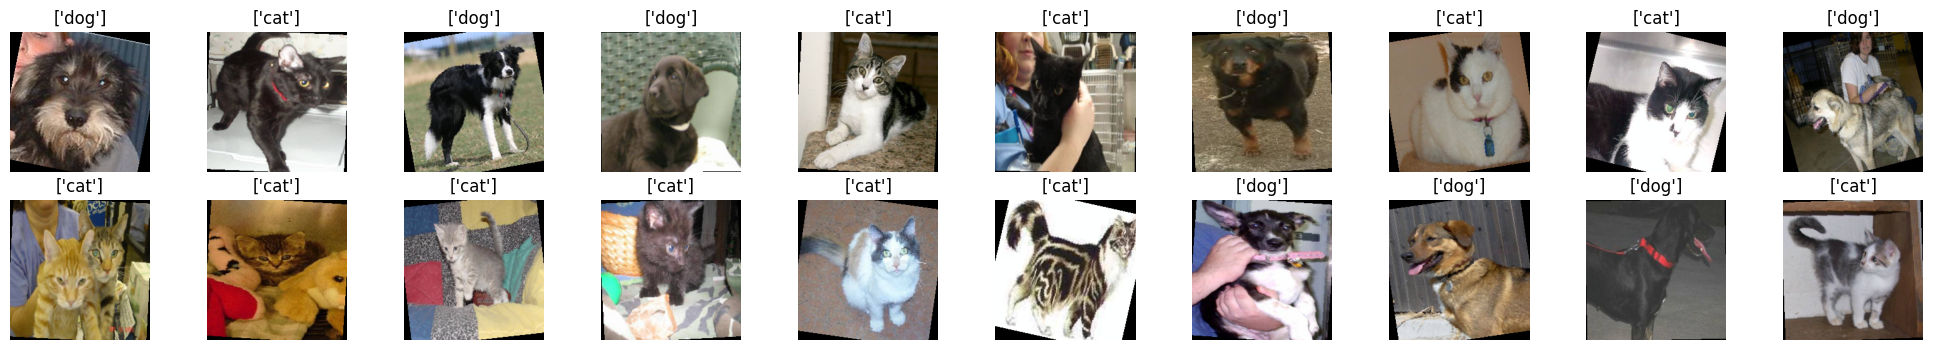

In [11]:
images, labels = next(iter(data_loaders["train"]))
fig, subs = plt.subplots(2, 10, figsize=(25, 4))
print(labels)
for i, sub in enumerate(subs.flatten()):
    my_helper.imshow(images[i], sub)
    sub.set_title([classes[labels[i]]])

In [12]:
taille_batch = data_loaders["train"].batch_size

In [13]:
images.size()

torch.Size([32, 3, 224, 224])

In [14]:
batch = next(iter(data_loaders["train"]))

# Pour un tenseur unique ou une liste de tenseurs
if isinstance(batch, torch.Tensor):
    # element_size() donne la taille en octets d'un élément (ex: float32 = 4 octets)
    # nelement() donne le nombre total d'éléments dans le tenseur
    taille_octets = batch.element_size() * batch.nelement()
else:
    # Si le batch est une liste ou un dictionnaire (ex: (images, labels))
    taille_octets = sum(b.element_size() * b.nelement() for b in batch if isinstance(b, torch.Tensor))

# Conversion en KB
taille_kb = taille_octets / 1024
taille_mb = taille_kb / 1024

print(f"Taille du batch : {taille_mb:.2f} MB")

Taille du batch : 18.38 MB


<Axes: >

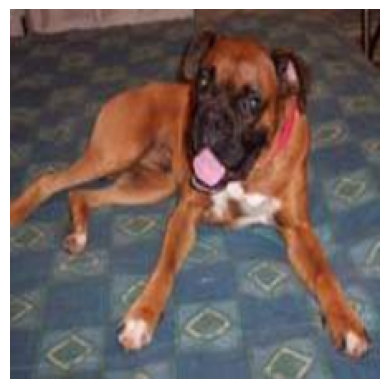

In [15]:
image, label = next(iter(data_loaders["val"]))
my_helper.imshow(image[0],title=f"Label: {label[0]}")

<Axes: >

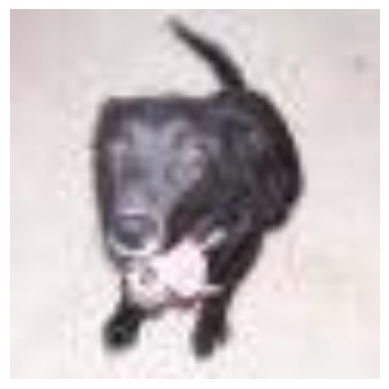

In [16]:
image, label = next(iter(data_loaders["test"]))
my_helper.imshow(image[0],title=f"Label: {label[0]}")

Conception du modèle

In [17]:
class CNNScratch(nn.Module):
    def __init__(self):
        super(CNNScratch, self).__init__()
        
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 2) 
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, acc_metric):
    model.train()
    acc_metric.reset()
    running_loss = 0.0
    for imgs, targets in tqdm(loader, desc="Train", ncols=100):
        imgs, targets = imgs.to(device,non_blocking=True), targets.to(device,non_blocking=True)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(logits, dim=1)
        acc_metric.update(preds, targets)
    return running_loss / len(loader.sampler), acc_metric.compute().item()

def evaluate(model, loader, criterion, acc_metric):
    model.eval()
    acc_metric.reset()
    running_loss = 0.0
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Valid", ncols=100):
            imgs, targets = imgs.to(device,non_blocking=True), targets.to(device,non_blocking=True)
            logits = model(imgs)
            loss = criterion(logits, targets)
            running_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(logits, dim=1)
            acc_metric.update(preds, targets)
    return running_loss / len(loader.sampler), acc_metric.compute().item()

def test_and_confusion(model, loader):
    model.eval()
    cm_metric = BinaryConfusionMatrix().to(device)
    test_acc.reset()
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Test", ncols=100):
            imgs, targets = imgs.to(device), targets.to(device)
            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)
            cm_metric.update(preds, targets)
            test_acc.update(preds, targets)
    cm = cm_metric.compute().cpu().numpy()
    acc = test_acc.compute().item()
    targets_cpu = targets.cpu().numpy()
    preds_cpu = preds.cpu().numpy()
    precision = precision_score(targets_cpu, preds_cpu, average='binary')
    recall = recall_score(targets_cpu, preds_cpu, average='binary')
    print(f"\nTest Accuracy : {acc:.4f}")
    print(f"Test Precision : {precision:.4f}")
    print(f"Test Recall : {recall:.4f}")
    print(f"Confusion Matrix :\n{cm}")
    return cm , f"{acc:.4f}", f"{precision:.4f}", f"{recall:.4f}"

def plot_confusion_matrix(cm, classes):
    confusion_matrix = pd.DataFrame(cm, index=classes, columns=classes)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    fig.savefig('confusion_matrix.png')
    plt.close()

def accuracy_by_class(cm, classes):
    print("\nAccuracy by class:\n")
    for i, class_name in enumerate(classes):
        correct_predictions = cm[i][i]
        total_predictions = cm[i].sum()
        accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
        print(f"    {class_name:11s}: {accuracy:.2f}")

def visualize_predictions(model, loader, classes, n_batches=1):
    model.eval()
    dataiter = iter(loader)
    for _ in range(n_batches):
        images, labels = next(dataiter)
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
        fig, subs = plt.subplots(2, 10, figsize=(25, 4))
        for i, ax in enumerate(subs.flatten()):
            img = images[i].cpu().numpy()
            img = img / 2 + 0.5  # unnormalize
            ax.imshow(np.transpose(img, (1, 2, 0)))
            ax.set_title(f"{classes[preds[i]]} ({classes[labels[i]]})",
                         color=("green" if preds[i] == labels[i] else "red"))
            ax.axis("off")
        plt.savefig('prediction_visualized.png')
        plt.close()

In [19]:
criterion = nn.CrossEntropyLoss()
train_acc = BinaryAccuracy().to(device)
valid_acc = BinaryAccuracy().to(device)
test_acc = BinaryAccuracy().to(device)

In [20]:
def suggest_hyperparameters(trial):
    # Obtain the learning rate on a logarithmic scale
    lr = trial.suggest_categorical("lr", [1e-4, 1e-3, 1e-2])

    # Obtain the optimizer to use by name
    optimizer_name = trial.suggest_categorical("optimizer_name", ["Adam", "SGD"])

    print(f"Hyperparamètres à tester: \n{pformat(trial.params)}")
    return lr, optimizer_name

In [21]:
def objective(trial):
    print("\n********************************\n")
    best_val = float("inf")
    lr, optimizer_name = suggest_hyperparameters(trial)
    print(f"Training on {device}")
    modele = CNNScratch().to(device)
    scripted = torch.jit.script(modele)
    torch.jit.save(scripted, "fromscratch_network.pt")
    if optimizer_name == "Adam":
        optimizer = optim.Adam(modele.parameters(), lr=lr)
    if optimizer_name == "SGD":
        optimizer = optim.SGD(modele.parameters(), lr=lr,momentum=0.9)
    scheduler = StepLR(optimizer, step_size=1, gamma=0.7)
    optuna_epochs = 10
    for epoch in range(1, optuna_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(modele, data_loaders["train"], criterion, optimizer, train_acc)
        val_loss, val_acc = evaluate(modele, data_loaders["val"], criterion, valid_acc)
        print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")
        if val_loss < best_val:
            best_val = val_loss
        scheduler.step()
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return best_val
study = optuna.create_study(study_name="optuna-cnn-fromscratch", direction="minimize")
study.optimize(objective, n_trials=6)

    # Print optuna study statistics
print("\n++++++++++++++++++++++++++++++++++\n")
print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))

print("Best trial:")
trial = study.best_trial

print("  Trial number: ", trial.number)
print("  Loss (trial value): ", trial.value)

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

    

[I 2026-06-03 11:08:55,660] A new study created in memory with name: optuna-cnn-fromscratch



********************************

Hyperparamètres à tester: 
{'lr': 0.01, 'optimizer_name': 'SGD'}
Training on cuda


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:04<00:00, 17.78it/s]


Epoch 01 | train loss 0.7493 acc 0.5025 | val loss 0.6933 acc 0.5016


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 22.26it/s]


...

Epoch 06 | train loss 0.4524 acc 0.7849 | val loss 0.4386 acc 0.7876


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 21.91it/s]


Epoch 07 | train loss 0.4366 acc 0.7983 | val loss 0.4167 acc 0.8028


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 20.42it/s]
[I 2026-06-03 12:06:21,771] Trial 5 pruned. 


Epoch 08 | train loss 0.4245 acc 0.8047 | val loss 0.4030 acc 0.8136

++++++++++++++++++++++++++++++++++

Study statistics: 
  Number of finished trials:  6
Best trial:
  Trial number:  2
  Loss (trial value):  0.37444682960510256
  Params: 
    lr: 0.001
    optimizer_name: Adam


In [22]:
best_params_scratch = {
    "lr": trial.params["lr"],
    "optimizer_name": trial.params["optimizer_name"]
}

In [23]:
val_loss_scratch = []
val_acc_scratch = []
test_acc_scratch = []
test_precision_scratch = []
test_recall_scratch = []

In [ ]:
def fromscratch():
    mlflow.set_tracking_uri("http://localhost:5000")
    mlflow.set_experiment(params["Experiment"])
    mlflow.config.enable_system_metrics_logging()
    print("✓ Successfully connected to MLflow!")
    with open('requirements.txt', 'r') as file:
        requirements_info = [line.strip() for line in file]
    
    best_val = float("inf")
    with mlflow.start_run(run_name="CNN_Scratch_Entrainement_Final"):
        mlflow.log_param("device", device)
        mlflow.log_params(params)
        lr = best_params_scratch["lr"]
        optimizer_name = best_params_scratch["optimizer_name"]
        mlflow.log_params(best_params_scratch)
        print(f"Hyperparamètres utilisés pour l'entraînement final: \n{pformat(best_params_scratch)}")
        print(f"Training on {device}")
        modele = CNNScratch().to(device)
        if optimizer_name == "Adam":
            optimizer = optim.Adam(modele.parameters(), lr=lr)
        if optimizer_name == "SGD":
            optimizer = optim.SGD(modele.parameters(), lr=lr,momentum=0.9)
        scheduler = StepLR(optimizer, step_size=1, gamma=0.7)
        for epoch in range(1, params["epochs"] + 1):
            tr_loss, tr_acc = train_one_epoch(modele, data_loaders["train"], criterion, optimizer, train_acc)
            val_loss, val_acc = evaluate(modele, data_loaders["val"], criterion, valid_acc)
            print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")
            mlflow.log_metrics({"train_loss": tr_loss, "train_accuracy": tr_acc, "val_loss": val_loss, "val_accuracy": val_acc}, step=epoch)
            val_loss_scratch.append(val_loss)
            val_acc_scratch.append(val_acc)
            if val_loss < best_val:
                best_val = val_loss
                torch.save(modele.state_dict(), params["save_path"])
                print("New best model saved!")
            scheduler.step()
        torch.load("best_scratch_model.pth")
        mlflow.pytorch.log_model(modele, name="final_model", pip_requirements="requirements.txt")
    
        # Final test + confusion matrix
        print("\nEvaluating on test set …")
        cm, test_acc,test_precision, test_recall = test_and_confusion(modele, data_loaders["test"])

        test_acc_scratch.append(test_acc)
        test_precision_scratch.append(test_precision)
        test_recall_scratch.append(test_recall)

        mlflow.log_metric("test_accuracy", test_acc)
        mlflow.log_metric("test_precision", test_precision)
        mlflow.log_metric("test_recall", test_recall)
        plot_confusion_matrix(cm, classes)
        os.replace('confusion_matrix.png', 'confusion_matrix_scratch.png')
        mlflow.log_artifact(os.getcwd()+"\\confusion_matrix_scratch.png", artifact_path="confusion_matrix")
        accuracy_by_class(cm,classes)

        visualize_predictions(modele,data_loaders['test'],classes)
        os.replace('prediction_visualized.png', 'prediction_visualized_scratch.png')
        mlflow.log_artifact(os.getcwd()+"\\prediction_visualized_scratch.png", artifact_path="prediction_visualized")

In [25]:
fromscratch()


2026/06/03 12:06:23 INFO mlflow.tracking.fluent: Experiment with name 'CNN_Cats&Dogs_Experiments' does not exist. Creating a new experiment.


✓ Successfully connected to MLflow!


2026/06/03 12:06:24 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Hyperparamètres utilisés pour l'entraînement final: 
{'lr': 0.001, 'optimizer_name': 'Adam'}
Training on cuda


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 21.57it/s]


...


Evaluating on test set …


Test: 100%|█████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 20.09it/s]



Test Accuracy : 0.8328
Test Precision : 1.0000
Test Recall : 1.0000
Confusion Matrix :
[[1070  189]
 [ 229 1012]]

Accuracy by class:

    cat        : 0.85
    dog        : 0.82


2026/06/03 12:27:23 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/06/03 12:27:23 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run CNN_Scratch_Entrainement_Final at: http://localhost:5000/#/experiments/1/runs/300c6320560f46ec840718a05f906dd0
🧪 View experiment at: http://localhost:5000/#/experiments/1


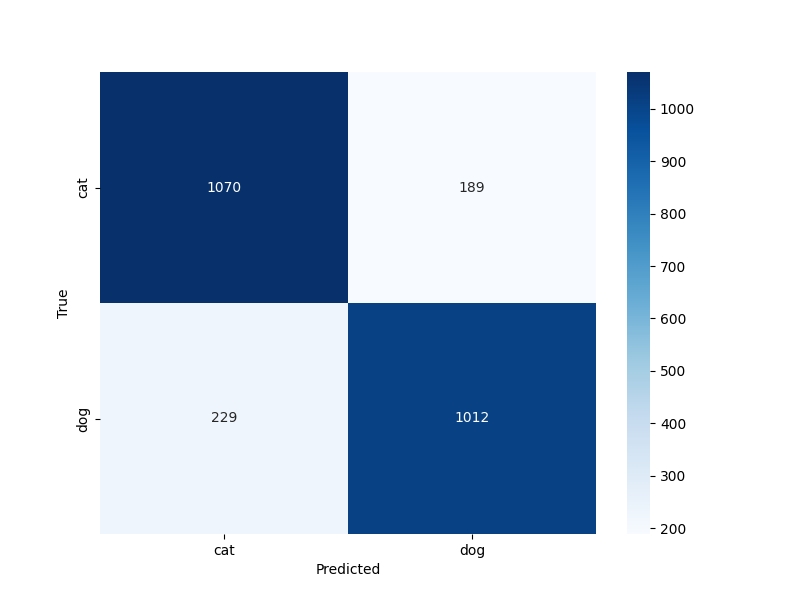

In [26]:
display(Image(filename='confusion_matrix_scratch.png', width=600))

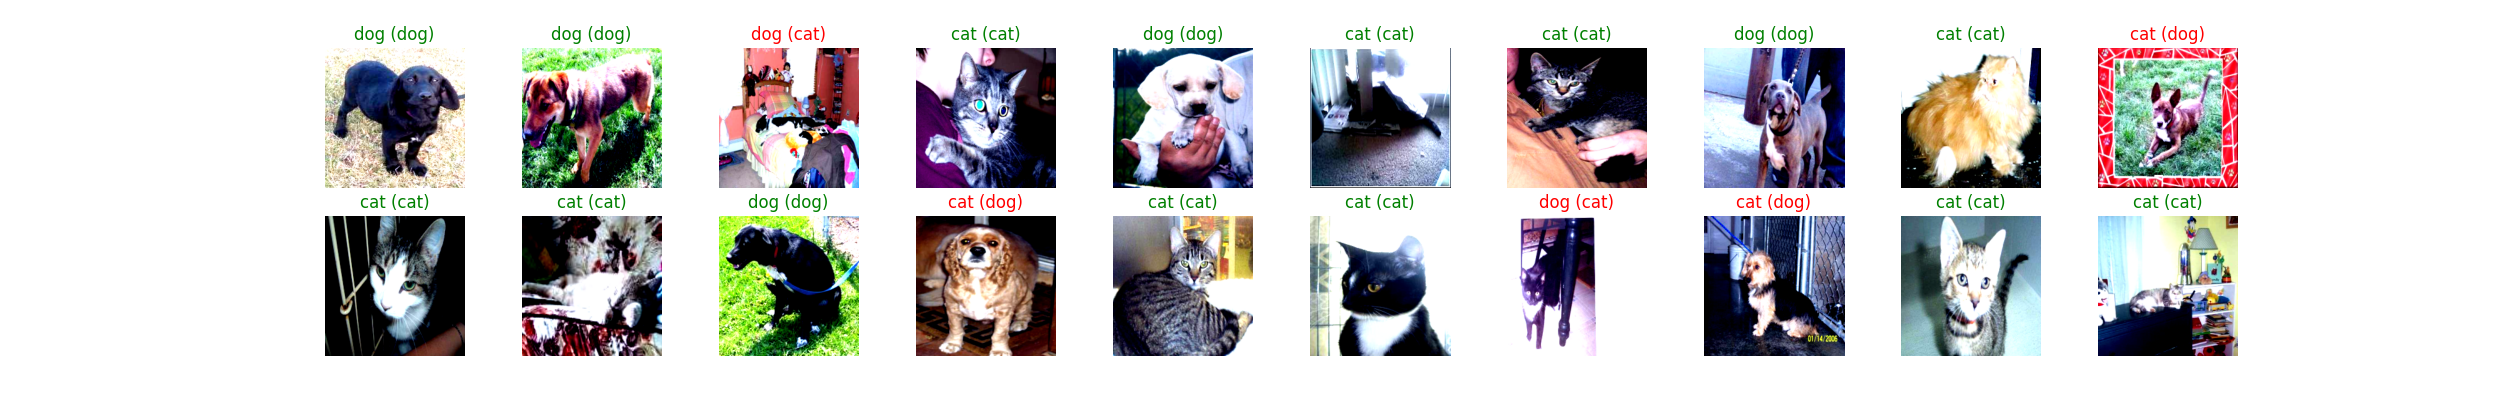

In [27]:
display(Image(filename='prediction_visualized_scratch.png', height=600))

In [28]:
criterion = nn.CrossEntropyLoss()
train_acc = BinaryAccuracy().to(device)
valid_acc = BinaryAccuracy().to(device)
test_acc = BinaryAccuracy().to(device)

In [29]:
def suggestion_hyperparametres(trial):
    lr = trial.suggest_categorical("lr", [1e-4, 1e-3, 1e-2])
    optimizer_name = trial.suggest_categorical("optimizer_name", ["Adam", "SGD"])
    couches_gel = trial.suggest_int("couches_gel", 1,8)
    print(f"Hyperparamètres à tester: \n{pformat(trial.params)}")
    return lr, optimizer_name, couches_gel
    

In [30]:
def objective(trial):
    
    print("\n********************************\n")
    best_val = float("inf")
    lr, optimizer_name, couches_gel = suggestion_hyperparametres(trial)
    print(f"Training on {device}")
    modele = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT).to(device)
    features = list(modele.features.children())

    total_features = len(features)

    layers_to_freeze = min(couches_gel, total_features)

    for i in range(layers_to_freeze):
        for param in features[i].parameters():
            param.requires_grad = False
    
    for i in range(layers_to_freeze, total_features):
        for param in features[i].parameters():
            param.requires_grad = True

    if optimizer_name == "Adam":
        optimizer = optim.Adam(modele.parameters(), lr=lr)
    if optimizer_name == "SGD":
        optimizer = optim.SGD(modele.parameters(), lr=lr,momentum=0.9)
    
    scheduler = StepLR(optimizer, step_size=1, gamma=0.7)
    nbre_param = modele.classifier[3].in_features
    modele.classifier[3] = nn.Linear(nbre_param, num_classes)
    modele = modele.to(device)
    
    optuna_epochs = 10
    for epoch in range(1, optuna_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(modele, data_loaders["train"], criterion, optimizer, train_acc)
        val_loss, val_acc = evaluate(modele, data_loaders["val"], criterion, valid_acc)
        print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")
        if val_loss < best_val:
            best_val = val_loss
        scheduler.step()
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return best_val

In [31]:
study = optuna.create_study(study_name="optuna-cnn-transfer", direction="minimize")
study.optimize(objective, n_trials=6)

[I 2026-06-03 12:27:24,008] A new study created in memory with name: optuna-cnn-transfer



********************************

Hyperparamètres à tester: 
{'couches_gel': 5, 'lr': 0.0001, 'optimizer_name': 'SGD'}
Training on cuda


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 25.02it/s]


Epoch 01 | train loss 0.6219 acc 0.7038 | val loss 0.5364 acc 0.8684


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 20.38it/s]


...

Epoch 09 | train loss 0.0053 acc 0.9984 | val loss 0.0238 acc 0.9920


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 21.59it/s]
[I 2026-06-03 13:13:45,080] Trial 4 finished with value: 0.021718544067814947 and parameters: {'lr': 0.01, 'optimizer_name': 'SGD', 'couches_gel': 3}. Best is trial 3 with value: 0.019130517998710274.


Epoch 10 | train loss 0.0049 acc 0.9987 | val loss 0.0236 acc 0.9912

********************************

Hyperparamètres à tester: 
{'couches_gel': 3, 'lr': 0.0001, 'optimizer_name': 'SGD'}
Training on cuda


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:04<00:00, 19.41it/s]
[I 2026-06-03 13:14:44,960] Trial 5 pruned. 


Epoch 01 | train loss 0.5902 acc 0.7777 | val loss 0.5135 acc 0.8832


In [32]:
print("\n++++++++++++++++++++++++++++++++++\n")
print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))

print("Best trial:")
trial = study.best_trial

print("  Trial number: ", trial.number)
print("  Loss (trial value): ", trial.value)

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))



++++++++++++++++++++++++++++++++++

Study statistics: 
  Number of finished trials:  6
Best trial:
  Trial number:  3
  Loss (trial value):  0.019130517998710274
  Params: 
    lr: 0.01
    optimizer_name: SGD
    couches_gel: 2


In [33]:
best_params_transfer = {
    "lr": trial.params["lr"],
    "optimizer_name": trial.params["optimizer_name"],
    "couches_gel": trial.params["couches_gel"]
}

In [34]:
print(best_params_transfer)

{'lr': 0.01, 'optimizer_name': 'SGD', 'couches_gel': 2}


In [35]:
val_loss_transfert = []
val_acc_transfert = []
test_acc_transfert = []
test_precision_transfert = []
test_recall_transfert = []

In [36]:
def transfert():
    mlflow.set_tracking_uri("http://localhost:5000")
    mlflow.set_experiment(params["Experiment"])
    mlflow.config.enable_system_metrics_logging()
    print("✓ Successfully connected to MLflow!")
    with open('requirements.txt', 'r') as file:
        requirements_info = [line.strip() for line in file]
    
    best_val = float("inf")
    with mlflow.start_run(run_name="CNN_transfert_Entrainement_Final"):
        mlflow.log_param("device", device)
        mlflow.log_params(params)
        print("\n********************************\n")
        print(f"Training final model on {device} with best hyperparameters")
        modele = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT).to(device)
        features = list(modele.features.children())

        total_features = len(features)

        layers_to_freeze = min(best_params_transfer["couches_gel"], total_features)

        for i in range(layers_to_freeze):
            for param in features[i].parameters():
                param.requires_grad = False
        
        for i in range(layers_to_freeze, total_features):
            for param in features[i].parameters():
                param.requires_grad = True

        if best_params_transfer["optimizer_name"] == "Adam":
            optimizer = optim.Adam(modele.parameters(), lr=best_params_transfer["lr"])
        if best_params_transfer["optimizer_name"] == "SGD":
            optimizer = optim.SGD(modele.parameters(), lr=best_params_transfer["lr"], momentum=0.9)
        
        scheduler = StepLR(optimizer, step_size=1, gamma=0.7)
        nbre_param = modele.classifier[3].in_features
        modele.classifier[3] = nn.Linear(nbre_param, num_classes)
        modele = modele.to(device)
        
        for epoch in range(1, params["epochs"] + 1):
            tr_loss, tr_acc = train_one_epoch(modele, data_loaders["train"], criterion, optimizer, train_acc)
            val_loss, val_acc = evaluate(modele, data_loaders["val"], criterion, valid_acc)
            print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")
            mlflow.log_metrics({"train_loss": tr_loss, "train_accuracy": tr_acc, "val_loss": val_loss, "val_accuracy": val_acc}, step=epoch)
            val_loss_transfert.append(val_loss)
            val_acc_transfert.append(val_acc)
            
            
            
            
            if val_loss < best_val:
                best_val = val_loss
                torch.save(modele.state_dict(), "best_transfer_model.pth")
                print("New best model saved!")
            scheduler.step()
        
        mlflow.pytorch.log_model(modele, name="final_model", pip_requirements="requirements.txt")
    
        # Final test + confusion matrix
        # Final test + confusion matrix
        print("\nEvaluating on test set …")
        cm, test_acc,test_precision, test_recall = test_and_confusion(modele, data_loaders["test"])
        test_acc_transfert.append(test_acc)
        test_precision_transfert.append(test_precision)
        test_recall_transfert.append(test_recall)
        mlflow.log_metric("test_accuracy", test_acc)
        mlflow.log_metric("test_precision", test_precision)
        mlflow.log_metric("test_recall", test_recall)
        plot_confusion_matrix(cm, classes)
        os.replace('confusion_matrix.png', 'confusion_matrix_transfer.png')
        mlflow.log_artifact(os.getcwd()+"\\confusion_matrix_transfer.png", artifact_path="confusion_matrix")
        accuracy_by_class(cm,classes)

        visualize_predictions(modele,data_loaders['test'],classes)
        os.replace('prediction_visualized.png', 'prediction_visualized_transfer.png')
        mlflow.log_artifact(os.getcwd()+"\\prediction_visualized_transfer.png", artifact_path="prediction_visualized")
    return best_val


In [37]:
best_val_transfert = transfert()

2026/06/03 13:14:47 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


✓ Successfully connected to MLflow!

********************************

Training final model on cuda with best hyperparameters


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:05<00:00, 15.44it/s]


Epoch 01 | train loss 0.0860 acc 0.9707 | val loss 0.0318 acc 0.9864
New best model saved!


Valid: 100%|████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 20.77it/s]


...


Evaluating on test set …


Test: 100%|█████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 20.47it/s]



Test Accuracy : 0.9928
Test Precision : 1.0000
Test Recall : 1.0000
Confusion Matrix :
[[1251    8]
 [  10 1231]]

Accuracy by class:

    cat        : 0.99
    dog        : 0.99


2026/06/03 13:36:16 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/06/03 13:36:16 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run CNN_transfert_Entrainement_Final at: http://localhost:5000/#/experiments/1/runs/dd723cec4230494e86058fb24a575ec4
🧪 View experiment at: http://localhost:5000/#/experiments/1


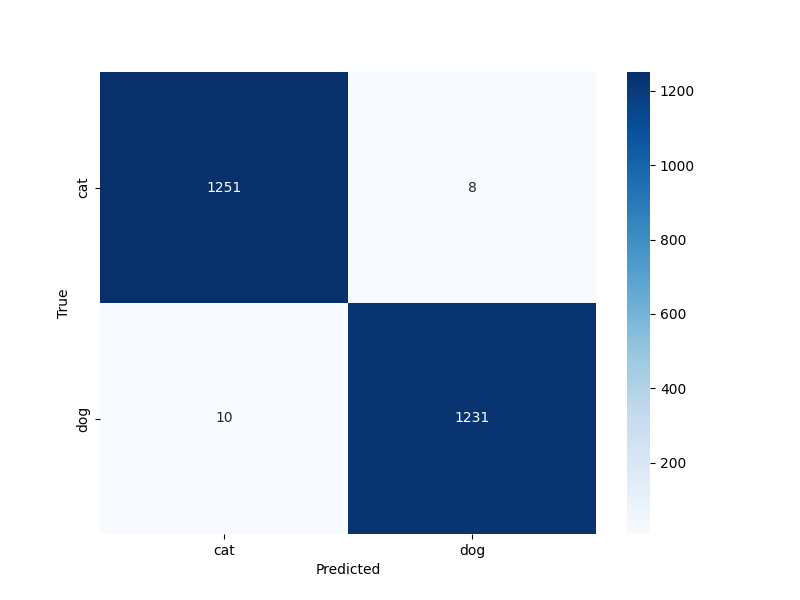

In [38]:
display(Image(filename='confusion_matrix_transfer.png', width=600))

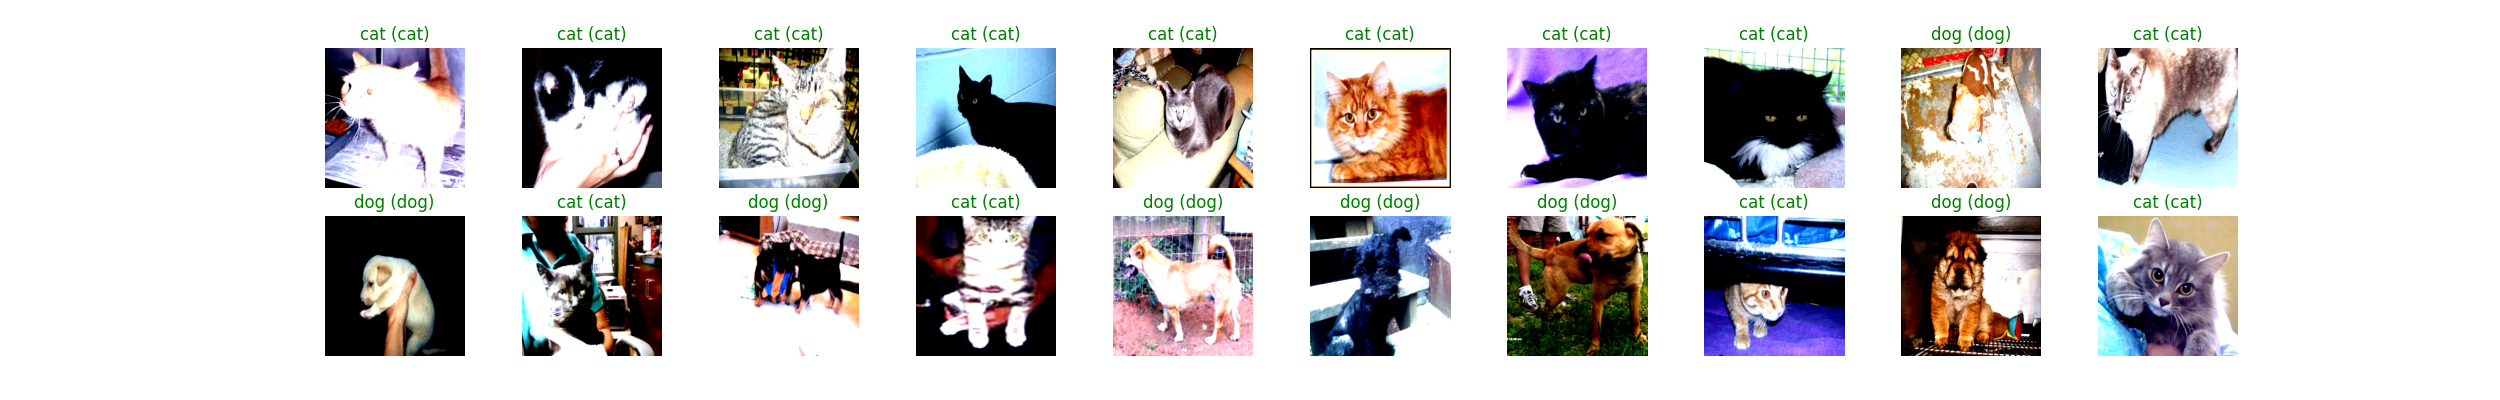

In [39]:
display(Image(filename='prediction_visualized_transfer.png', height=600))

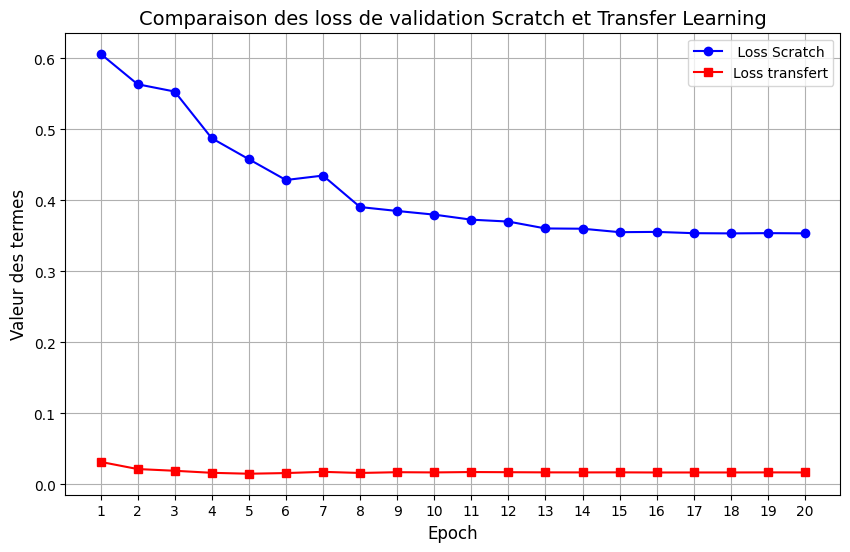

In [40]:
epoques = list(range(1,21))
plt.figure(figsize=(10, 6))

plt.plot(epoques, val_loss_scratch, color='blue', marker='o', label=' Loss Scratch')
plt.plot(epoques, val_loss_transfert, color='red', marker='s', label='Loss transfert')

# 4. Mise en page
plt.title('Comparaison des loss de validation Scratch et Transfer Learning', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Valeur des termes', fontsize=12)
plt.xticks(epoques) # Force l'affichage de chaque graduation de 1 à 20
plt.legend()
plt.grid(True)

# 5. Affichage
plt.show()

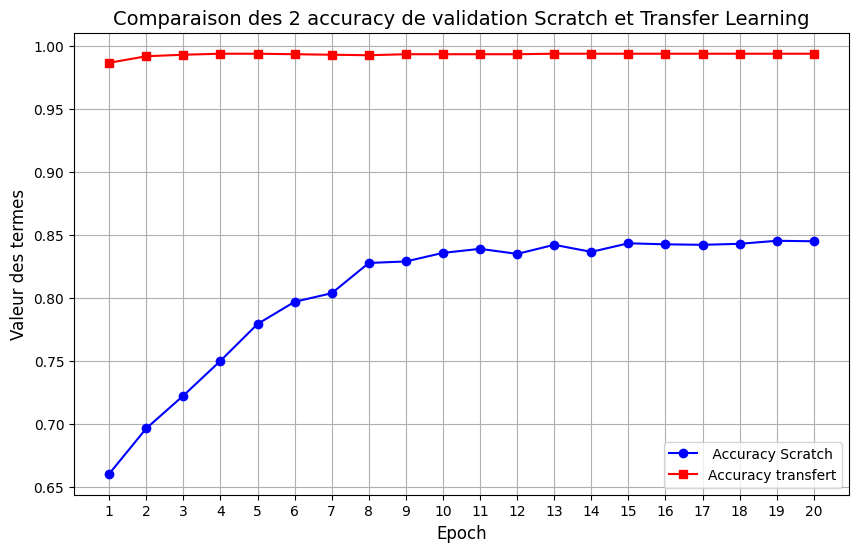

In [41]:
epoques = list(range(1,21))
plt.figure(figsize=(10, 6))

plt.plot(epoques, val_acc_scratch, color='blue', marker='o', label=' Accuracy Scratch')
plt.plot(epoques, val_acc_transfert, color='red', marker='s', label='Accuracy transfert')

# 4. Mise en page
plt.title('Comparaison des 2 accuracy de validation Scratch et Transfer Learning', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Valeur des termes', fontsize=12)
plt.xticks(epoques) # Force l'affichage de chaque graduation de 1 à 20
plt.legend()
plt.grid(True)

# 5. Affichage
plt.show()

In [42]:
tableau_comparatif = pd.DataFrame({
    "Modèle": ["Scratch", "Transfert"],
    "Test Accuracy": [test_acc_scratch[0], test_acc_transfert[0]],
    "Test Precision": [test_precision_scratch[0], test_precision_transfert[0]],
    "Test Recall": [test_recall_scratch[0], test_recall_transfert[0]]
})

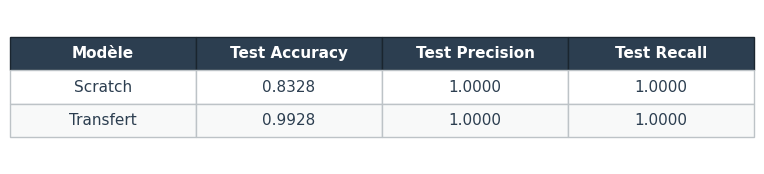

In [43]:

# Extraction des colonnes et des valeurs du DataFrame
col_labels = tableau_comparatif.columns
cell_text = tableau_comparatif.values

# Configuration de la figure Matplotlib (ajustez figsize selon vos besoins)
fig, ax = plt.subplots(figsize=(8, 2))

# Masquer les axes standards du graphique pour ne garder que le tableau
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

# Création du tableau Matplotlib
table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

# --- STYLISATION DU TABLEAU ---

# 1. Ajustement de la taille des cellules (Largeur, Hauteur)
table.scale(1.2, 2.0)

# 2. Personnalisation de la police et des couleurs
table.auto_set_font_size(False)
#table.set_facecolor('#ffffff')

for (row, col), cell in table.get_celld().items():
    # Définir la taille du texte pour toutes les cellules
    cell.set_fontsize(11)
    
    if row == 0:
        # Style de la ligne d'en-tête (Header)
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2C3E50')  # Bleu foncé élégant
        cell.set_edgecolor('#1A252F')
    else:
        # Style des lignes de données
        cell.set_text_props(weight='normal', color='#2C3E50')
        cell.set_edgecolor('#BDC3C7')
        
        # Effet d'alternance de couleur (Zebra striping) optionnel
        if row % 2 == 0:
            cell.set_facecolor('#F8F9F9')

# Rendu final
plt.show()
